# H100 — fused matrix assembly

LDC cases, all four strategies, Float64 GPU measurements from `standalone-gpu.csv`.

Throughput is **million cells per second**, computed as `cells / (time_mean_ms × 1000)`.
Each CSV measurement is drawn individually, including repeated case/strategy runs;
no averaging or deduplication is applied. The logarithmic x-axis spans all mesh sizes;
the throughput axis is linear. Timing uses the recorded mean assembly time.

Colors identify strategies; open circles mark individual measurements.


In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import EngFormatter

# Support launching from variants/, the repository root, or notebooks/.
candidates = [Path("standalone-gpu.csv"), Path("variants/standalone-gpu.csv"),
              Path("../variants/standalone-gpu.csv")]
data_path = next((p.resolve() for p in candidates if p.is_file()), None)
if data_path is None:
    raise FileNotFoundError("Cannot locate variants/standalone-gpu.csv")

# This file has no header; explicitly name columns so the first row is retained.
columns = "time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case,case_long,strategy,variant,language,precision,executor,use_kernelAbstractions,use_fusing,Threads,nnz,node".split(",")
raw = pd.read_csv(data_path, names=columns, header=None, skip_blank_lines=True)
strategies = {
    "batchedFace": "Face-Based Batched",
    "faceBased": "Face-Based",
    "globalfaceBased": "Face-Based Global",
    "cellBased": "Cell-Based",
}
nodes = ['H100']
for column in ["node", "executor", "variant", "strategy", "precision"]:
    raw[column] = raw[column].astype(str).str.strip()
data = raw.loc[
    raw["node"].isin(nodes) & raw["executor"].eq("gpu")
    & raw["variant"].eq("Fused") & raw["precision"].eq("float64")
    & raw["strategy"].isin(strategies)
].copy()
data["cells"] = pd.to_numeric(data["case"].str.extract(r"^LDC-(\d+)$", expand=False), errors="raise")
data["time_mean_ms"] = pd.to_numeric(data["time_mean_ms"], errors="raise")
assert not data.empty and data["cells"].notna().all()
assert data["time_mean_ms"].gt(0).all()
data["throughput_mcells_s"] = data["cells"] / (data["time_mean_ms"] * 1000)
data = data.sort_values(["node", "strategy", "cells"])
coverage = data.groupby(["node", "strategy"]).agg(
    measurements=("cells", "size"), cases=("cells", "nunique")
)
print(f"Source: {data_path}\n{len(data)} measurements (duplicates retained)")
display(coverage)


Source: /storage/home/lupeterm/FVM-Prototyping/variants/standalone-gpu.csv
124 measurements (duplicates retained)


measurements  cases
node strategy                            
H100 batchedFace                31     30
     cellBased                  31     30
     faceBased                  31     30
     globalfaceBased            31     30

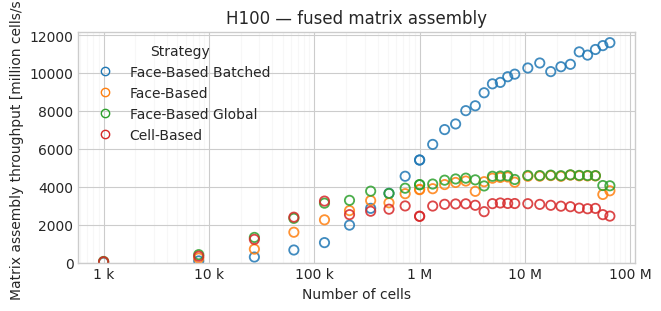

In [5]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(6.5, 3), constrained_layout=True)
colors = dict(zip(strategies, plt.get_cmap("tab10").colors))
for strategy, label in strategies.items():
    for node in nodes:
        points = data.loc[data["strategy"].eq(strategy) & data["node"].eq(node)]
        ax.scatter(points["cells"], points["throughput_mcells_s"],
                   s=45, marker="o", edgecolors=colors[strategy],
                   facecolors=colors[strategy] if node == "H200" else "none",
                   linewidths=1.3, alpha=0.85)
ax.set(xscale="log", xlabel="Number of cells", ylabel="Matrix assembly throughput [million cells/s]",
       title='H100 — fused matrix assembly')
ax.xaxis.set_major_formatter(EngFormatter())
ax.set_ylim(bottom=0)
ax.grid(True, which="minor", alpha=0.15)
strategy_handles = [Line2D([], [], color=colors[s], marker="o", linestyle="none",
                           markerfacecolor="none", label=label)
                    for s, label in strategies.items()]
legend = ax.legend(handles=strategy_handles, title="Strategy", loc="upper left")
if len(nodes) > 1:
    ax.add_artist(legend)
    ax.legend(handles=[Line2D([], [], color="0.25", marker="o", linestyle="none",
                              markerfacecolor="none" if node == "H100" else "0.25",
                              label=node) for node in nodes], title="GPU", loc="lower right")
plt.show()


Optional: export the figure next to the input CSV.

In [6]:
# fig.savefig(data_path.parent / "h100_fused_throughput.svg", bbox_inches="tight")
# fig.savefig(data_path.parent / "h100_fused_throughput.png", dpi=200, bbox_inches="tight")
